Name: Aagman Karki
<BR>
ID: 2509866
<BR>
Github Repo Link: [REPO LINK](https://github.com/AaKkMe/2509866_DSA#)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# 3.1
# To read csv
df = pd.read_csv("/content/drive/MyDrive/Coursework/Coursework.csv")

**1. Data Exploration and Understanding:**


*Dataset Overview*

In [ ]:
# 1. Load the dataset and display the first 10 rows
df.head(10)

,Country name,score,Log GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Dystopia + residual
0,Finland,7.741,1.844,1.572,0.695,0.859,0.142,0.546,2.082
1,Denmark,7.583,1.908,1.520,0.699,0.823,0.204,0.548,1.881
2,Iceland,7.525,1.881,1.617,0.718,0.819,0.258,0.182,2.050
3,Sweden,7.344,1.878,1.501,0.724,0.838,0.221,0.524,1.658
4,Israel,7.341,1.803,1.513,0.740,0.641,0.153,0.193,2.298
5,Netherlands,7.319,1.901,1.462,0.706,0.725,0.247,0.372,1.906
6,Norway,7.302,1.952,1.517,0.704,0.835,0.224,0.484,1.586
7,Luxembourg,7.122,2.141,1.355,0.708,0.801,0.146,0.432,1.540
8,Switzerland,7.060,1.970,1.425,0.747,0.759,0.173,0.498,1.488
9,Australia,7.057,1.854,1.461,0.692,0.756,0.225,0.323,1.745


In [ ]:
# 2. Identify the number of rows and columns in the dataset.

print("No. of (Rows, Columns): ", df.shape)

No. of (Rows, Columns):  (143, 9)


In [ ]:
# 3. List all the columns and their data types.
df.dtypes

,0
Country name,object
score,float64
Log GDP per capita,float64
Social support,float64
Healthy life expectancy,float64
Freedom to make life choices,float64
Generosity,float64
Perceptions of corruption,float64
Dystopia + residual,float64


In [ ]:
# 1. Calculate the mean, median, and standard deviation for the Score column.

df["score"].agg(['mean', 'median', 'std'])

,score
mean,5.527580
median,5.785000
std,1.170717


In [ ]:
# 2. Identify the country with the highest and lowest happiness scores.

happiest = df.loc[df['score'].idxmax()]
saddest = df.loc[df['score'].idxmin()]

print(f"\nHappiest Country is {happiest['Country name']} with ({happiest['score']})")
print(f"Least Happy Country is {saddest['Country name']} with ({saddest['score']})")



Happiest Country is Finland with (7.741)
Least Happy Country is Afghanistan with (1.721)


*Missing Values*

In [ ]:
# Check if there are any missing values in the dataset. If so, display the total count for each column.

# Count missing values
missing = df.isnull().sum()

# Labelling the columns
missing_df = pd.DataFrame({
    "Column": missing.index,
    "Missing Values": missing.values
})


print(missing_df)



                         Column  Missing Values
0                  Country name               0
1                         score               0
2            Log GDP per capita               3
3                Social support               3
4       Healthy life expectancy               3
5  Freedom to make life choices               3
6                    Generosity               3
7     Perceptions of corruption               3
8           Dystopia + residual               3


Filtering and Sorting

In [ ]:
# 1. Filter the dataset to show only the countries with a Score greater than 7.5.
high_score_df = df[df['score'] > 7.5].copy()

high_score_df


,Country name,score,Log GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Dystopia + residual
0,Finland,7.741,1.844,1.572,0.695,0.859,0.142,0.546,2.082
1,Denmark,7.583,1.908,1.520,0.699,0.823,0.204,0.548,1.881
2,Iceland,7.525,1.881,1.617,0.718,0.819,0.258,0.182,2.050


In [ ]:
top_gdp_high_score = high_score_df.sort_values(by='Log GDP per capita', ascending=False).head(10)

print("\nCountries with Score > 7.5 sorted by GDP:")
display(top_gdp_high_score[['Country name', 'score', 'Log GDP per capita']])


Countries with Score > 7.5 sorted by GDP:


,Country name,score,Log GDP per capita
1,Denmark,7.583,1.908
2,Iceland,7.525,1.881
0,Finland,7.741,1.844


*Adding New Columns*

In [ ]:
def categorize_happiness(score):
    if score < 4:
        return 'Low'
    elif 4 <= score <= 6:
        return 'Medium'
    else:
        return 'High'

df['Happiness_Category'] = df['score'].apply(categorize_happiness)

print("\nCategory Counts:")
print(df['Happiness_Category'].value_counts())


Category Counts:
Happiness_Category
Medium    70
High      56
Low       17
Name: count, dtype: int64


*Data VIsualizations:*

/tmp/ipython-input-892054485.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10, x='score', y='Country name', palette='viridis')


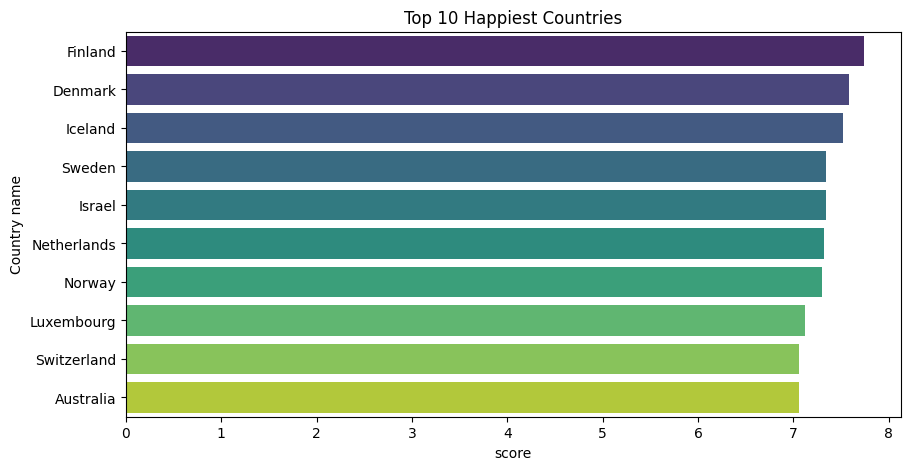

In [ ]:
# Bar Plot: Plot the top 10 happiest countries by Score using a bar chart.

top10 = df.nlargest(10, 'score')
plt.figure(figsize=(10, 5))
sns.barplot(data=top10, x='score', y='Country name', palette='viridis')
plt.title('Top 10 Happiest Countries')
plt.show()


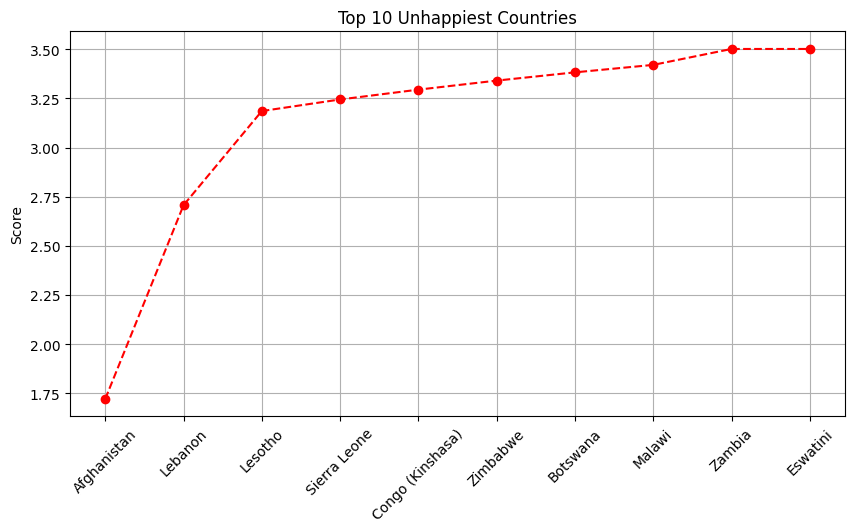

In [ ]:
#  Top 10 Unhappiest, Line Plot
bottom10 = df.nsmallest(10, 'score')
plt.figure(figsize=(10, 5))
plt.plot(bottom10['Country name'], bottom10['score'], marker='o', color='red', linestyle='--')
plt.title('Top 10 Unhappiest Countries')
plt.xticks(rotation=45)
plt.ylabel('Score')
plt.grid(True)
plt.show()

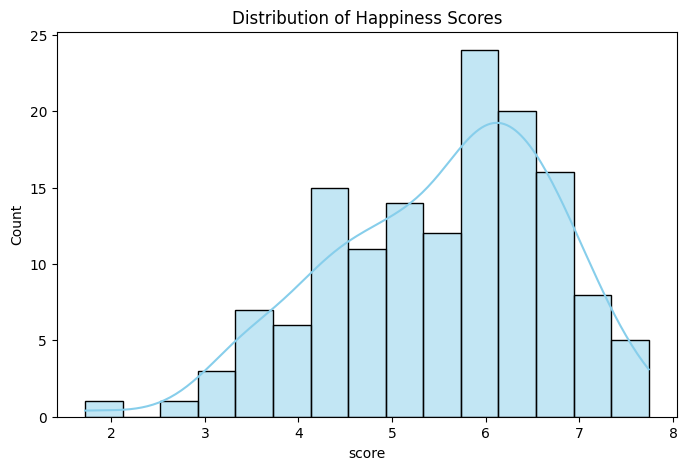

In [ ]:
# 3. Histogram of Score
plt.figure(figsize=(8, 5))
sns.histplot(df['score'], kde=True, bins=15, color='skyblue')
plt.title('Distribution of Happiness Scores')
plt.xlabel('score')
plt.show()

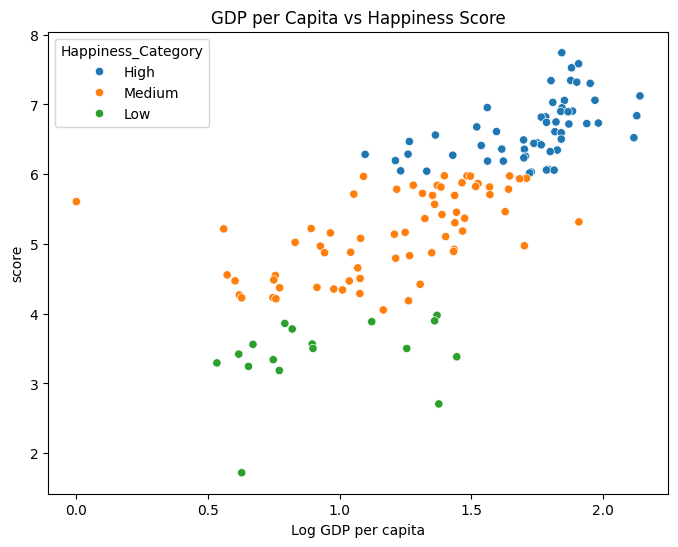

In [ ]:
# 4. Scatter Plot (GDP vs Score)
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Log GDP per capita', y='score', hue='Happiness_Category')
plt.title('GDP per Capita vs Happiness Score')
plt.show()

**Problem - 2 - Some Advance Data Exploration Task:**

*Task - 1 - Setup Task - Preparing the South-Asia Dataset:*

In [ ]:
sa_countries_list = ["Afghanistan", "Bangladesh", "Bhutan", "India", "Maldives", "Nepal", "Pakistan", "Sri Lanka"]

# Define the countries in South Asia

# Filtering
sa_df = df[df['Country name'].isin(sa_countries_list)].copy()

print("South Asian Countries found in dataset:")
print(sa_df['Country name'].unique())

sa_df.to_csv('South_Asia_Dataset.csv', index=False)


South Asian Countries found in dataset:
['Nepal' 'Pakistan' 'India' 'Sri Lanka' 'Bangladesh' 'Afghanistan']


*Task 2: Composite Score Ranking*

In [ ]:
sa_df['Composite Score'] = (
    0.40 * sa_df['Log GDP per capita'] + 0.30 * sa_df['Social support']
    +  0.30 * sa_df['Healthy life expectancy']
)

sa_ranked = sa_df.sort_values(by='Composite Score', ascending=False)


/tmp/ipython-input-932580643.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sa_ranked.head(5), x='Composite Score', y='Country name', palette='magma')


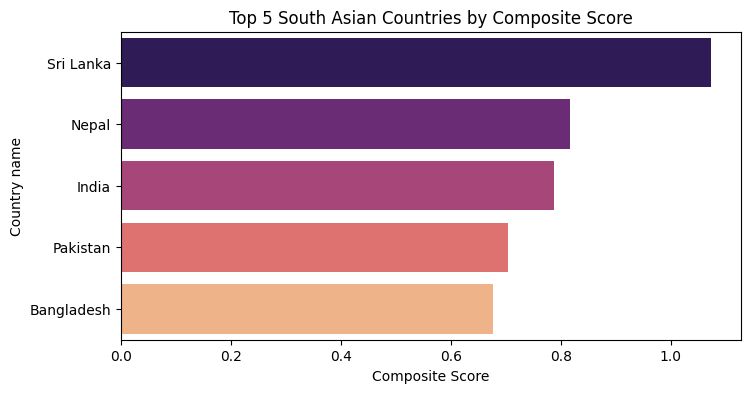

In [ ]:
# Visualize Top 5
plt.figure(figsize=(8, 4))
sns.barplot(data=sa_ranked.head(5), x='Composite Score', y='Country name', palette='magma')
plt.title('Top 5 South Asian Countries by Composite Score')
plt.show()


Comparison of Rankings:
    Country name  score  Composite Score
127    Sri Lanka  3.898           1.0739
92         Nepal  5.158           0.8159
125        India  4.054           0.7874
107     Pakistan  4.657           0.7039
128   Bangladesh  3.886           0.6774
142  Afghanistan  1.721           0.3238


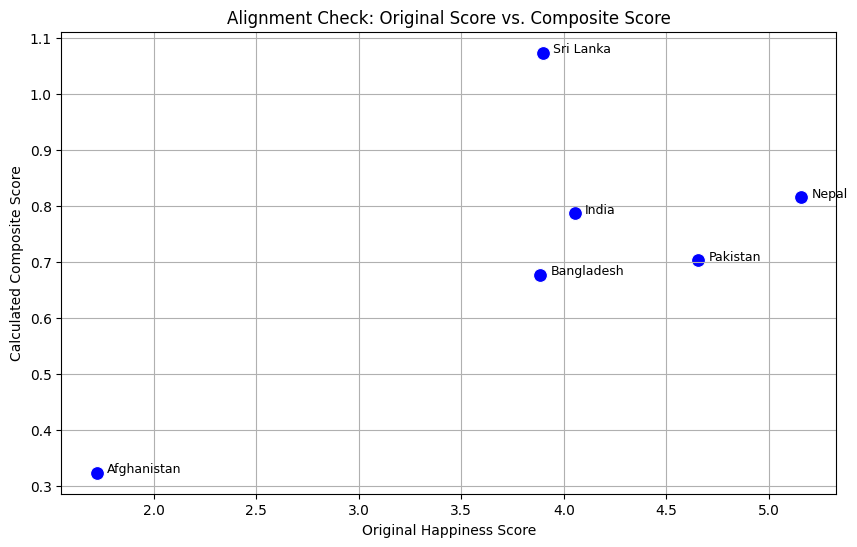

In [ ]:
# Original Rank vs Composite Rank
print("\nComparison of Rankings:")
print(sa_ranked[['Country name', 'score', 'Composite Score']])

plt.figure(figsize=(10, 6))
sns.scatterplot(data=sa_df, x='score', y='Composite Score', s=100, color='blue')

# Add labels for countries
for i in range(sa_df.shape[0]):
    plt.text(
        sa_df.iloc[i]['score'] + 0.05,
        sa_df.iloc[i]['Composite Score'],
        sa_df.iloc[i]['Country name'],
        fontsize=9
    )

plt.title('Alignment Check: Original Score vs. Composite Score')
plt.xlabel('Original Happiness Score')
plt.ylabel('Calculated Composite Score')
plt.grid(True)
plt.show()

*TASK-3- Outlier Detecion*

In [ ]:
# # 1. Identify outlier countries in South Asia based on their Score and GDP per Capita.
# 2. Define outliers using the 1.5 × IQR rule.

# Calculate IQR for 'Score'
Q1 = sa_df['score'].quantile(0.25)
Q3 = sa_df['score'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"IQR Bounds for Score: {lower_bound:.2f} to {upper_bound:.2f}")

# Identify outliers
outliers = sa_df[(sa_df['score'] < lower_bound) | (sa_df['score'] > upper_bound)]
print("Outlier Countries in South Asia based on Score:")
print(outliers['Country name'].tolist())


IQR Bounds for Score: 2.96 to 5.43
Outlier Countries in South Asia based on Score:
['Afghanistan']


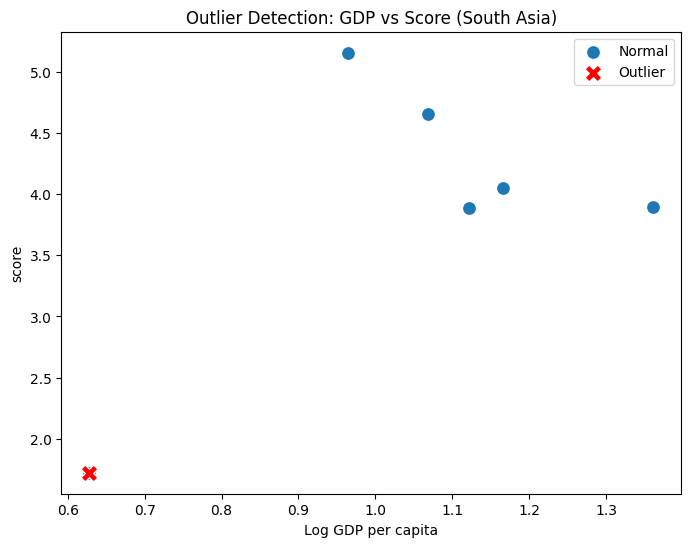

In [ ]:
# 3. Create a scatter plot with GDP per Capita on the x-axis and Score on the y-axis, highlighting outliers
# in a different color
# Plotting
plt.figure(figsize=(8, 6))
# Plot regular points
sns.scatterplot(data=sa_df, x='Log GDP per capita', y='score', label='Normal', s=100)
# Highlight outliers
if not outliers.empty:
    sns.scatterplot(data=outliers, x='Log GDP per capita', y='score',
                    color='red', label='Outlier', s=150, marker='X')
plt.title('Outlier Detection: GDP vs Score (South Asia)')
plt.legend()
plt.show()


**Task - 4 - Exploring Trends Across Metrics:**

In [ ]:
# 1. Choose two metrics (e.g., Freedom to Make Life Choices and Generosity) and calculate their correlation
# {pearson correlation} with the Score for South Asian countries.

metrics = ['Freedom to make life choices', 'Generosity']
corr_freedom = sa_df['score'].corr(sa_df[metrics[0]])
corr_generosity = sa_df['score'].corr(sa_df[metrics[1]])

print(f"Correlation (Score vs Freedom): {corr_freedom:.3f}")
print(f"Correlation (Score vs Generosity): {corr_generosity:.3f}")


Correlation (Score vs Freedom): 0.801
Correlation (Score vs Generosity): 0.875


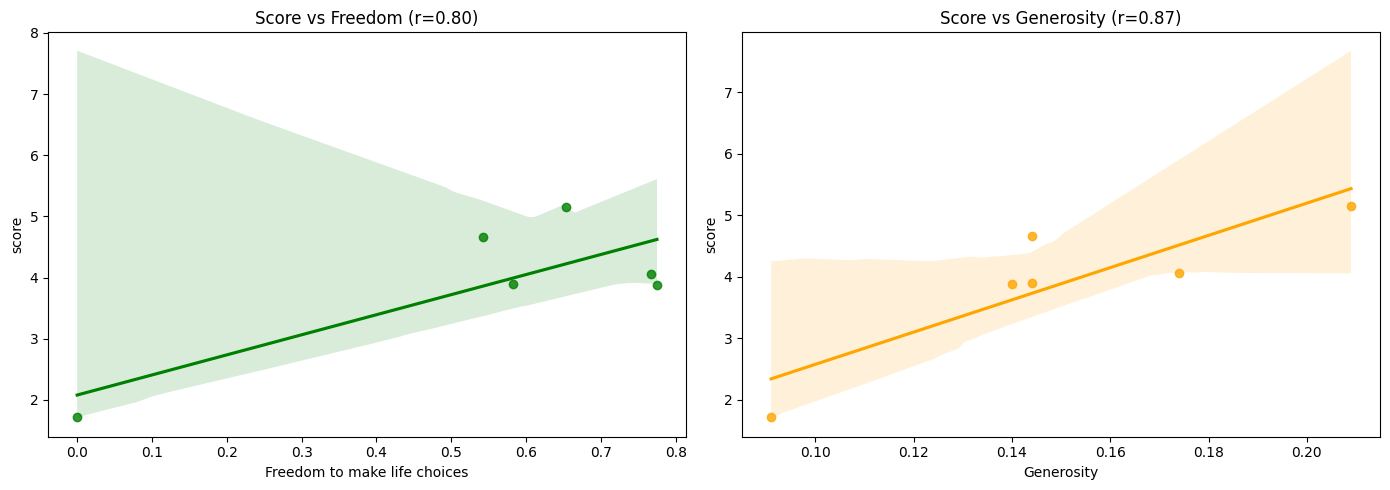

In [ ]:
# 2. Create scatter plots with trendlines for these metrics against the Score.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.regplot(data=sa_df, x='Freedom to make life choices', y='score', ax=axes[0], color='green')
axes[0].set_title(f'Score vs Freedom (r={corr_freedom:.2f})')

sns.regplot(data=sa_df, x='Generosity', y='score', ax=axes[1], color='orange')
axes[1].set_title(f'Score vs Generosity (r={corr_generosity:.2f})')

plt.tight_layout()
plt.show()

In [ ]:
# 3. Identify and discuss the strongest and weakest relationships between these metrics and the Score for
# South Asian countries

**Task-5 - Gap Analysis**

In [ ]:
# 1. Add a new column, GDP-Score Gap, which is the difference between GDP per Capita and the Score
# for each South Asian country
sa_df['GDP-Score Gap'] = sa_df['Log GDP per capita'] - sa_df['score']

sa_df['GDP-Score Gap']


,GDP-Score Gap
92,-4.193
107,-3.588
125,-2.888
127,-2.537
128,-2.764
142,-1.093


In [ ]:
# 2. Rank the South Asian countries by this gap in both ascending and descending order.
gap_ranked = sa_df.sort_values(by='GDP-Score Gap', ascending=False)

gap_ranked


,Country name,score,Log GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Dystopia + residual,Happiness_Category,Composite Score,GDP-Score Gap
142,Afghanistan,1.721,0.628,0.000,0.242,0.000,0.091,0.088,0.672,Low,0.3238,-1.093
127,Sri Lanka,3.898,1.361,1.179,0.586,0.583,0.144,0.031,0.014,Low,1.0739,-2.537
128,Bangladesh,3.886,1.122,0.249,0.513,0.775,0.140,0.167,0.919,Low,0.6774,-2.764
125,India,4.054,1.166,0.653,0.417,0.767,0.174,0.122,0.756,Medium,0.7874,-2.888
107,Pakistan,4.657,1.069,0.600,0.321,0.542,0.144,0.074,1.907,Medium,0.7039,-3.588
92,Nepal,5.158,0.965,0.990,0.443,0.653,0.209,0.115,1.783,Medium,0.8159,-4.193


/tmp/ipython-input-2753228048.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=combined_gap, x='GDP-Score Gap', y='Country name', palette='coolwarm')


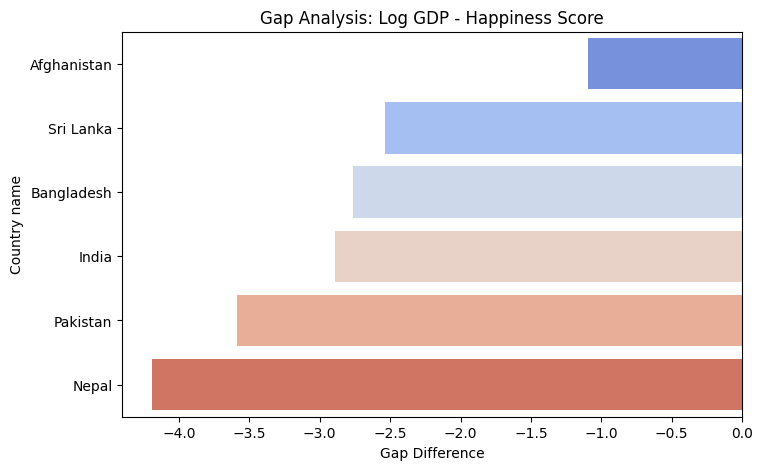

In [ ]:
# 3. Highlight the top 3 countries with the largest positive and negative gaps using a bar chart.

top_3_gap = gap_ranked.head(3)
bottom_3_gap = gap_ranked.tail(3)
combined_gap = pd.concat([top_3_gap, bottom_3_gap])

plt.figure(figsize=(8, 5))
sns.barplot(data=combined_gap, x='GDP-Score Gap', y='Country name', palette='coolwarm')
plt.title('Gap Analysis: Log GDP - Happiness Score')
plt.xlabel('Gap Difference')
plt.show()


In [ ]:
print("4. Analyze the reasons behind these gaps and their implications for South Asian countries")

4. Analyze the reasons behind these gaps and their implications for South Asian countries


**Problem-3 - Comparative Analysis**

In [ ]:
me_countries_list = [
    "Bahrain", "Iran", "Iraq", "Israel", "Jordan", "Kuwait", "Lebanon",
    "Oman", "State of Palestine", "Qatar", "Saudi Arabia", "Syria",
    "United Arab Emirates", "Yemen"
]

me_df = df[df['Country name'].isin(me_countries_list)].copy()

# Add a Region tag to both dataframes for easier plotting
sa_df['Region'] = 'South Asia'
me_df['Region'] = 'Middle East'

# Combine them
combined_df = pd.concat([sa_df, me_df])
print(f"Middle East countries found: {len(me_df)}")

Middle East countries found: 11


*1. Descriptive Statistics:*

In [ ]:
# • Calculate the mean, Standard deviation of the score for both South Asia and Middle East.
# • Which region has higher happiness Scores on average?

# Groupby Region and get stats
region_stats = combined_df.groupby('Region')['score'].agg(['mean', 'std'])
print("\nRegional Statistics for Score:")
display(region_stats)



Regional Statistics for Score:


,mean,std
Region,,
Middle East,5.363636,1.494498
South Asia,3.895667,1.177069


*2. Top and Bottom Performers*

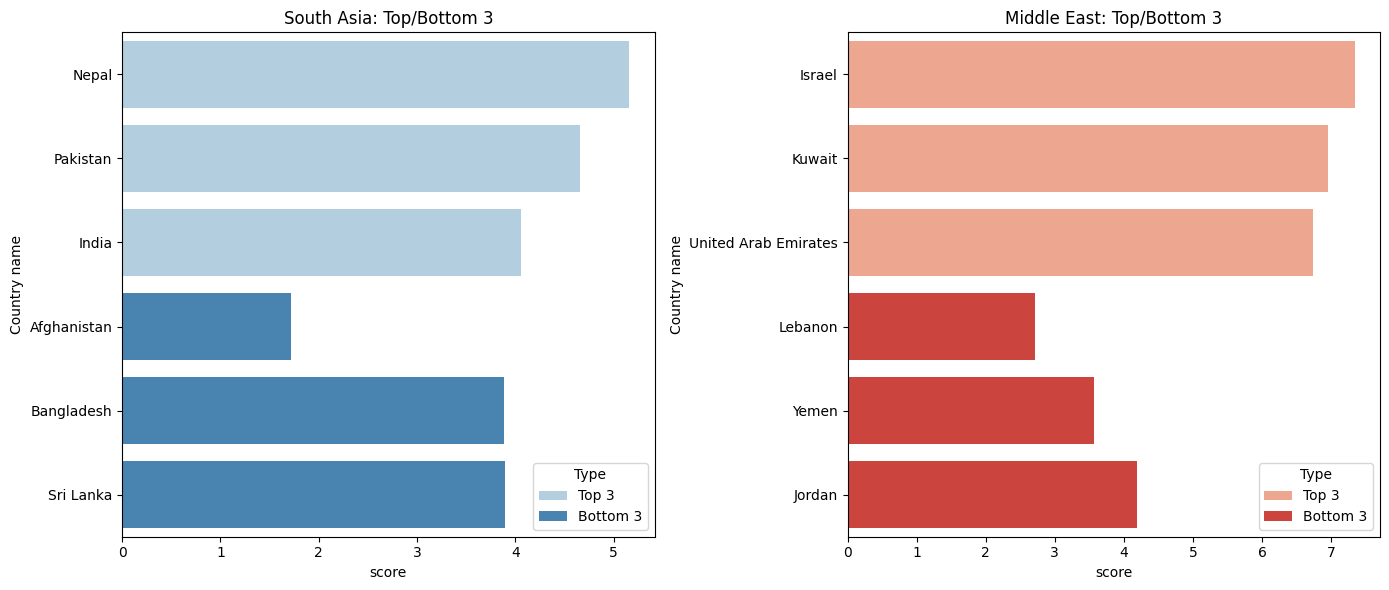

In [ ]:
# • Identify the top 3 and bottom 3 countries in each region based on the score.
def get_top_bottom(data, name):
    top3 = data.nlargest(3, 'score')
    bot3 = data.nsmallest(3, 'score')
    top3['Type'] = 'Top 3'
    bot3['Type'] = 'Bottom 3'
    return pd.concat([top3, bot3])

sa_extremes = get_top_bottom(sa_df, 'South Asia')
me_extremes = get_top_bottom(me_df, 'Middle East')

# • Plot bar charts comparing these charts.


fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(data=sa_extremes, x='score', y='Country name', hue='Type', ax=axes[0], palette='Blues')
axes[0].set_title('South Asia: Top/Bottom 3')

sns.barplot(data=me_extremes, x='score', y='Country name', hue='Type', ax=axes[1], palette='Reds')
axes[1].set_title('Middle East: Top/Bottom 3')

plt.tight_layout()
plt.show()

*3. Metric Comparisons*

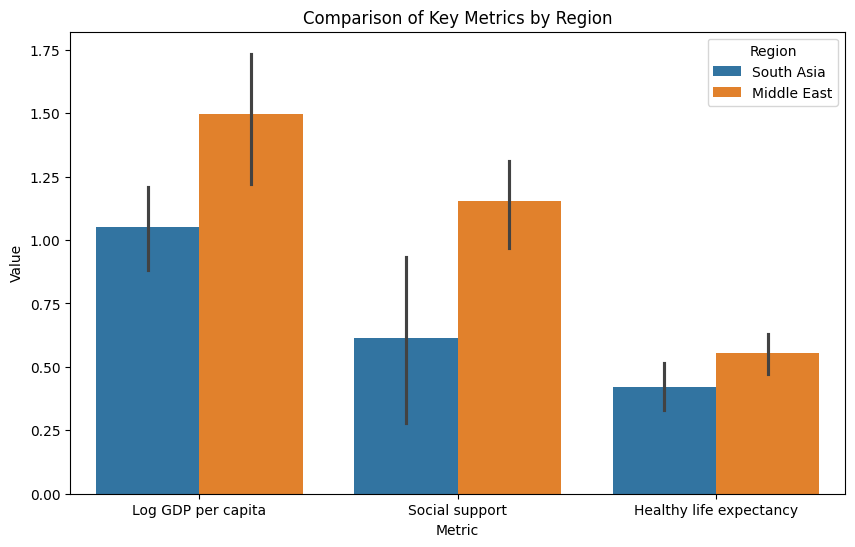

In [ ]:
# • Compare key metrics like GDP per Capita, Social Support, and Healthy Life Expectancy
# between the regions using grouped bar charts
metrics_to_compare = ['Log GDP per capita', 'Social support', 'Healthy life expectancy']
melted = combined_df.melt(id_vars='Region', value_vars=metrics_to_compare, var_name='Metric', value_name='Value')

plt.figure(figsize=(10, 6))
sns.barplot(data=melted, x='Metric', y='Value', hue='Region')
plt.title('Comparison of Key Metrics by Region')
plt.show()



*Happiness Disparity:*

In [ ]:
# Compare key metrics like GDP per Capita, Social Support, and Healthy Life Expectancy
# between the regions using grouped bar charts.

for region in ['South Asia', 'Middle East']:
    subset = combined_df[combined_df['Region'] == region]
    score_range = subset['score'].max() - subset['score'].min()
    cv = (subset['score'].std() / subset['score'].mean()) * 100

    print(f"\n{region}:")
    print(f"Range: {score_range:.3f}")
    print(f"CV: {cv:.2f}%")





South Asia:
Range: 3.437
CV: 30.21%

Middle East:
Range: 4.634
CV: 27.86%


*Correlation Analysis:*


Correlations (Score vs Freedom/Generosity):
South Asia -> Freedom: 0.80, Generosity: 0.87
Middle East -> Freedom: 0.86, Generosity: 0.63


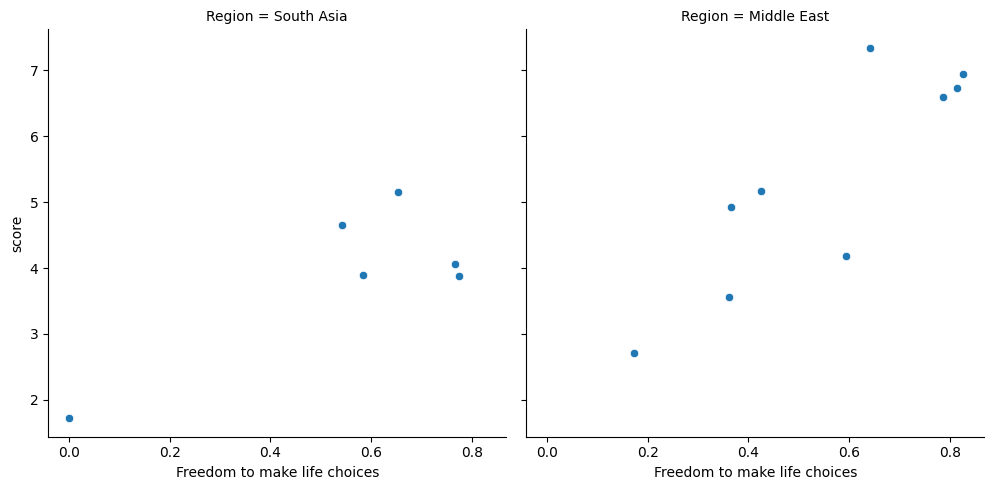

In [ ]:
# Analyze the correlation of Score with other metrics Freedom to Make Life Choices, and
# Generosity within each region

print("\nCorrelations (Score vs Freedom/Generosity):")
for region in ['South Asia', 'Middle East']:
    subset = combined_df[combined_df['Region'] == region]
    corr_f = subset['score'].corr(subset['Freedom to make life choices'])
    corr_g = subset['score'].corr(subset['Generosity'])
    print(f"{region} -> Freedom: {corr_f:.2f}, Generosity: {corr_g:.2f}")

# • Create scatter plots to visualize and interpret the relationships.
g = sns.FacetGrid(combined_df, col="Region", height=5)
g.map(sns.scatterplot, "Freedom to make life choices", "score")
g.add_legend()
plt.show()




*Outlier Detection*


Outliers identified in South Asia:
    Country name  score  Log GDP per capita
142  Afghanistan  1.721               0.628


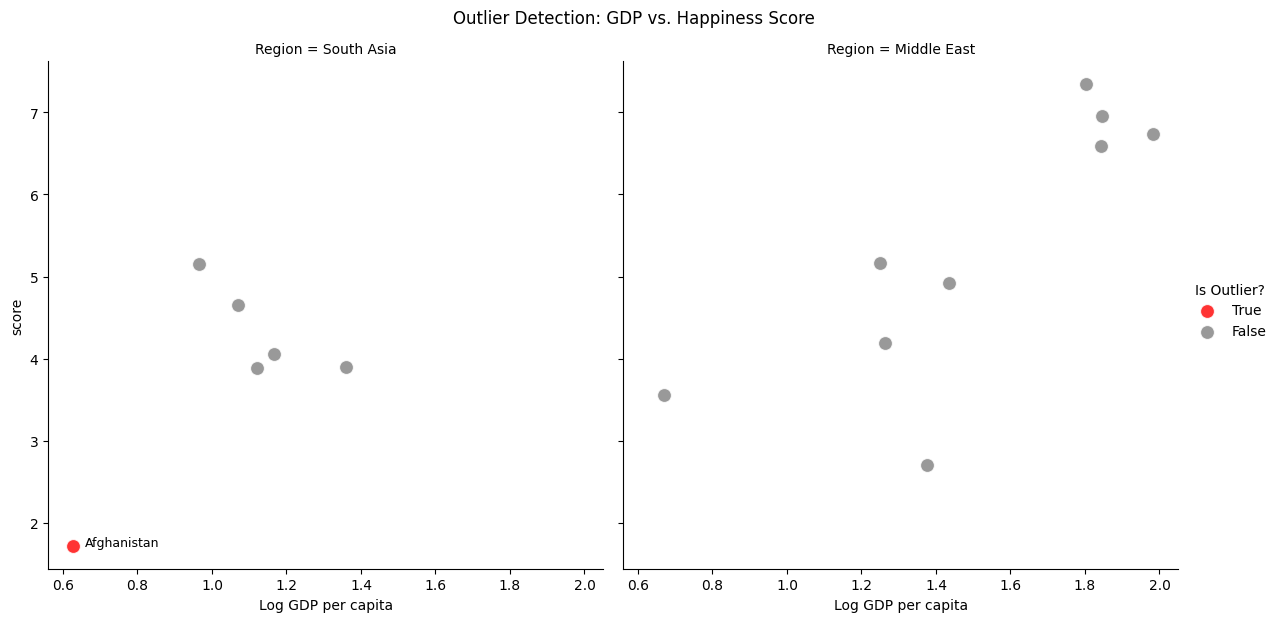

In [ ]:
outlier_indices = []

# Loop through each region to calculate its specific outliers
for region in ['South Asia', 'Middle East']:
    region_df = combined_df[combined_df['Region'] == region]

    # Calculate IQR for Score
    Q1_score = region_df['score'].quantile(0.25)
    Q3_score = region_df['score'].quantile(0.75)
    IQR_score = Q3_score - Q1_score
    lower_bound_score = Q1_score - 1.5 * IQR_score
    upper_bound_score = Q3_score + 1.5 * IQR_score

    # Calculate IQR for Log GDP per capita
    Q1_gdp = region_df['Log GDP per capita'].quantile(0.25)
    Q3_gdp = region_df['Log GDP per capita'].quantile(0.75)
    IQR_gdp = Q3_gdp - Q1_gdp
    lower_bound_gdp = Q1_gdp - 1.5 * IQR_gdp
    upper_bound_gdp = Q3_gdp + 1.5 * IQR_gdp

    # Find outliers for either metric
    outliers = region_df[
        (region_df['score'] < lower_bound_score) | (region_df['score'] > upper_bound_score) |
        (region_df['Log GDP per capita'] < lower_bound_gdp) | (region_df['Log GDP per capita'] > upper_bound_gdp)
    ]

    # Store the indices of the outlier countries
    if not outliers.empty:
        outlier_indices.extend(outliers.index.tolist())
        print(f"\nOutliers identified in {region}:")
        print(outliers[['Country name', 'score', 'Log GDP per capita']])

# --- Step 2: Plot the Outliers ---

# Create a new column to mark outliers for easy plotting
combined_df['is_outlier'] = False
combined_df.loc[outlier_indices, 'is_outlier'] = True

# Create a FacetGrid to plot each region in a separate subplot
g = sns.FacetGrid(combined_df, col="Region", hue="is_outlier",
                  hue_order=[True, False], palette={True: 'red', False: 'gray'}, height=6)

# Map the scatter plot to the grid
g.map(sns.scatterplot, 'Log GDP per capita', 'score', s=100, alpha=0.8)

# Add labels to the outlier points for clarity
for ax in g.axes.flat:
    region_name = ax.get_title().replace("Region = ", "")
    region_outliers = combined_df[(combined_df['Region'] == region_name) & (combined_df['is_outlier'])]
    for _, row in region_outliers.iterrows():
        ax.text(row['Log GDP per capita'] + 0.03, row['score'], row['Country name'], fontsize=9, color='black')

g.add_legend(title="Is Outlier?")
g.fig.suptitle('Outlier Detection: GDP vs. Happiness Score', y=1.03) # y > 1 to raise title
plt.show()

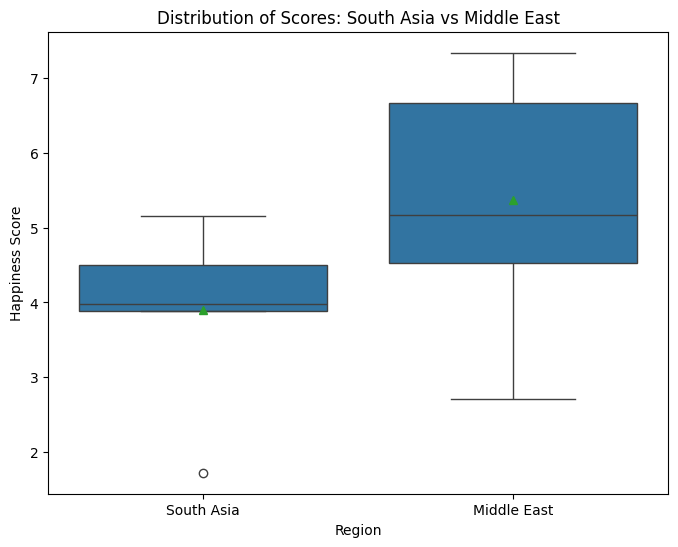

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=combined_df, x='Region', y='score', showmeans=True)
plt.title('Distribution of Scores: South Asia vs Middle East')
plt.ylabel('Happiness Score')
plt.show()